In [1]:
!pip -q install datasets

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score

In [3]:
dataset = load_dataset("cardiffnlp/tweet_eval", "sentiment")
labels = ["negative", "neutral", "positive"]

train_df = dataset["train"].to_pandas()
valid_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

print(train_df.shape, valid_df.shape, test_df.shape)
print(train_df["label"].value_counts(normalize=True).sort_index())

README.md:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

sentiment/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.78MB            

sentiment/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

sentiment/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  901kB            

sentiment/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

sentiment/validation-00000-of-00001.parq(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

(45615, 2) (2000, 2) (12284, 2)
label
0    0.155497
1    0.453206
2    0.391297
Name: proportion, dtype: float64


El corpus presenta un desbalance moderado entre las clases, con menor representación de la clase negativa. Por esta razón, el uso de class_weight="balanced" en la regresión logística es adecuado y el F1 macro resulta más informativo que una métrica global aislada.

In [4]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=3,
        max_features=25_000
    )),
    ("classifier", LogisticRegression(
        max_iter=1_000,
        class_weight="balanced",
        random_state=42
    ))
])

model.fit(train_df["text"], train_df["label"])

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=25000, min_df=3,
                                 ngram_range=(1, 2))),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [5]:
valid_pred = model.predict(valid_df["text"])

print(
    "F1 macro validación:",
    f1_score(valid_df["label"], valid_pred, average="macro")
)

F1 macro validación: 0.6409956505285027


In [6]:
test_pred = model.predict(test_df["text"])

print(
    classification_report(
        test_df["label"],
        test_pred,
        target_names=labels,
        digits=3
    )
)

              precision    recall  f1-score   support

    negative      0.556     0.676     0.610      3972
     neutral      0.654     0.536     0.589      5937
    positive      0.546     0.594     0.569      2375

    accuracy                          0.593     12284
   macro avg      0.585     0.602     0.589     12284
weighted avg      0.601     0.593     0.592     12284



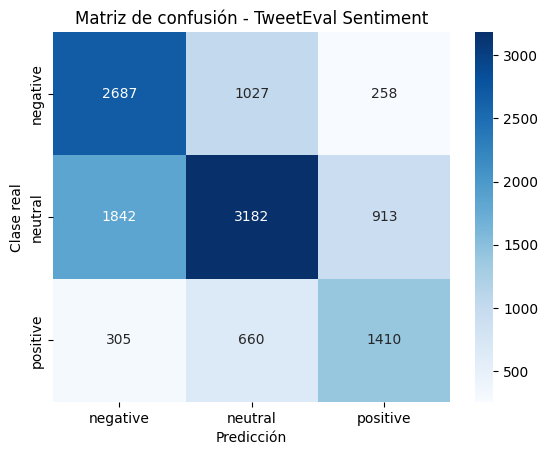

In [7]:
cm = confusion_matrix(test_df["label"], test_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicción")
plt.ylabel("Clase real")
plt.title("Matriz de confusión - TweetEval Sentiment")
plt.show()

El modelo presenta un desempeño moderado y relativamente equilibrado entre las tres clases, aunque la clase neutral obtiene el menor recall (0.536). La matriz de confusión evidencia una confusión considerable entre mensajes neutrales y negativos, lo cual puede relacionarse con la dificultad de interpretar textos breves cuyo tono depende del contexto, la negación, la ironía o expresiones ambiguas.

In [8]:
errors = test_df.copy()
errors["prediction"] = test_pred
errors = errors[errors["label"] != errors["prediction"]]

errors["real"] = errors["label"].map(dict(enumerate(labels)))
errors["predicted"] = errors["prediction"].map(dict(enumerate(labels)))

sample_errors = errors[
    ["text", "real", "predicted"]
].sample(20, random_state=42)

sample_errors

,text,real,predicted
9140,"With the most powerful binoculars, I cannot se...",neutral,positive
8021,@user The dividing lines that these new fascis...,negative,neutral
10816,@user #CapitalistArmy #MemeWars against libera...,negative,neutral
11987,How Medical Marijuana Could Combat the Opioid ...,neutral,negative
10374,2/2 #Yanukovich to #Ukraine ppl: @user give or...,neutral,negative
241,#Marijuana is medicine. 4 a very authoritative...,neutral,negative
3475,Vernon RCMP Cracking Down on Medical Marijuana...,neutral,negative
8541,Anyone else realised that getting a #Hatchimal...,neutral,negative
1217,Eat out and stay #Healthy. Yes. It is possible...,positive,neutral
4892,"Sodastream:.How to profit from Occupation, Opp...",neutral,negative


Los errores parecen estar relacionados principalmente con falta de contexto y ambigüedad entre lenguaje informativo y lenguaje emocional. También pueden intervenir ironía, hashtags y polaridad implícita. Esto es consistente con la dificultad del modelo para distinguir especialmente entre las clases neutral y negative.

### Discusión: errores relacionados con negación, ironía o falta de contexto

**¿Qué errores parecen relacionados con negación, ironía o falta de contexto?**

La revisión de 20 errores muestra que la **falta de contexto** es la dificultad predominante. Varios tweets son titulares informativos que contienen vocabulario con fuerte carga negativa —por ejemplo, *crisis*, *war*, *sanctions*, *oppression* o *apartheid*— aunque su etiqueta real sea neutral.

También se observaron casos de **humor, ironía y referencias culturales**, como menciones a *Terminator 3* o críticas políticas formuladas de manera indirecta. Asimismo, aparece al menos un caso de **negación explícita** mediante la palabra *cannot*.

Estos ejemplos evidencian una limitación del enfoque **TF-IDF**, ya que identifica patrones léxicos, pero no siempre captura adecuadamente el contexto, la intención, la ironía o la composición semántica del mensaje.

In [9]:
assert len(test_pred) == len(test_df)
assert set(np.unique(test_pred)).issubset({0, 1, 2})
assert "tfidf" in model.named_steps
assert "classifier" in model.named_steps

print("Verificaciones superadas")

Verificaciones superadas


### Discusión: clase con menor recall

**¿Qué clase obtiene menor recall?**

La clase **neutral** obtiene el menor recall, con un valor de **0.536**. Esto indica que el modelo identifica correctamente aproximadamente el 53.6 % de los tweets realmente neutrales.

La matriz de confusión muestra que una parte importante de los tweets neutrales es clasificada como negativa: **1,842 casos neutral → negative**. También se observan **913 casos neutral → positive**.

Este comportamiento sugiere que la neutralidad es especialmente difícil de distinguir cuando los textos contienen palabras asociadas con conflictos, problemas sociales, política o situaciones negativas, aunque el mensaje tenga un carácter principalmente informativo.

### Discusión: costo de los falsos negativos

**¿Cambiaría la decisión si los falsos negativos tuvieran mayor costo?**

Sí. Si los falsos negativos tuvieran un costo mayor, no sería suficiente seleccionar el modelo únicamente por su F1 macro o accuracy global.

En ese escenario sería necesario prestar mayor atención al **recall de la clase de interés**, ya que un falso negativo implica que un mensaje perteneciente realmente a una clase relevante no sea detectado.

Dependiendo del contexto de aplicación, podría ser necesario ajustar el umbral de decisión, utilizar métricas ponderadas, modificar los pesos de las clases o comparar modelos alternativos que prioricen la recuperación de la clase con mayor costo asociado.


### Discusión: aplicación a mensajes dominicanos en español

**¿Qué limitaciones tendría aplicar el modelo a mensajes dominicanos en español?**

El modelo tendría limitaciones importantes porque fue entrenado con tweets en **inglés** y dentro del dominio específico de TweetEval.

Aplicarlo directamente a mensajes dominicanos en español introduciría una fuerte diferencia de idioma, dominio y contexto cultural. El modelo no fue entrenado para reconocer vocabulario español, expresiones dominicanas, modismos, abreviaciones, formas coloquiales, errores ortográficos, emojis utilizados localmente ni referencias culturales propias de República Dominicana.

Además, la **jerga dominicana** representa una dificultad adicional, ya que muchas expresiones, dobles sentidos, frases populares y usos coloquiales solo pueden interpretarse correctamente dentro del contexto cultural dominicano. Una misma expresión podría parecer neutral o incluso positiva para un modelo extranjero, cuando para un hablante dominicano tiene una connotación negativa, irónica o sarcástica.

Por estas razones, el modelo no debería utilizarse directamente sobre mensajes dominicanos en español sin realizar un nuevo proceso de entrenamiento o adaptación con datos representativos del idioma, la jerga y el contexto sociocultural dominicano.